# Embedding Model Comparison: specter_v2 vs text-embedding-3-small

Structured comparison of two embedding approaches over the shared paper corpus to determine which better serves the literature-review search use case.

| Property | specter_v2 | text-embedding-3-small |
|----------|-----------|------------------------|
| Dimensions | 768 | 1536 |
| Source | Semantic Scholar API | OpenAI API |
| Training domain | Scientific papers | General (web) |
| DB run_id | 1 | 2 |

## Section 0 — Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sqlalchemy import text
from literature_ai.db import ENGINE

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
SPECTER_RUN_ID = 1
OPENAI_RUN_ID = 2
RNG = np.random.default_rng(42)

In [2]:
# Confirm both runs exist
with ENGINE.connect() as conn:
    runs = pd.read_sql(
        "SELECT run_id, embedding_model, n_dim, source, ran_at "
        "FROM processed.embedding_runs_metadata ORDER BY run_id",
        conn
    )
display(runs)

,run_id,embedding_model,n_dim,source,ran_at
0,1,specter_v2,768,collect,2026-07-12 20:07:55.810141+00:00
1,2,text-embedding-3-small,1536,generate,2026-07-12 20:08:06.227625+00:00


In [3]:
# Load all papers that have BOTH embeddings
LOAD_SQL = text("""
    SELECT
        ae1."paperId",
        r.title,
        r.year,
        r."citationCount",
        r."fieldsOfStudy",
        ae1.embedding_768   AS specter_emb,
        ae2.embedding_1536  AS openai_emb
    FROM processed.abstract_embeddings ae1
    JOIN processed.abstract_embeddings ae2
        ON ae1."paperId" = ae2."paperId" AND ae2.run_id = :oa_run
    JOIN raw.raw_paper_searches r
        ON ae1."paperId" = r."paperId"
    WHERE ae1.run_id = :sp_run
      AND ae1.embedding_768  IS NOT NULL
      AND ae2.embedding_1536 IS NOT NULL
""")

with ENGINE.connect() as conn:
    df = pd.read_sql(LOAD_SQL, conn, params={'sp_run': SPECTER_RUN_ID, 'oa_run': OPENAI_RUN_ID})

print(f"Overlap corpus: {len(df)} papers")

# Parse embedding strings → numpy arrays
def _parse_vec(s):
    return np.array(s[1:-1].split(','), dtype=np.float32)

X_sp = np.vstack(df['specter_emb'].map(_parse_vec).values)   # (N, 768)
X_oa = np.vstack(df['openai_emb'].map(_parse_vec).values)    # (N, 1536)

# Parse fieldsOfStudy (JSONB list or None)
def _primary_field(fos):
    if fos is None or (isinstance(fos, float) and np.isnan(fos)):
        return 'Unknown'
    if isinstance(fos, list) and len(fos) > 0:
        return fos[0]
    return 'Unknown'

df['field'] = df['fieldsOfStudy'].apply(_primary_field)
df['log_citations'] = np.log10(df['citationCount'].fillna(0).clip(lower=1))

print(f"specter_v2 shape: {X_sp.shape}")
print(f"text-embedding-3-small shape: {X_oa.shape}")

Overlap corpus: 200 papers
specter_v2 shape: (200, 768)
text-embedding-3-small shape: (200, 1536)


## Section 1 — Embedding Space Properties

**Metrics:**
- **L2 norm distribution** — how uniformly "long" the vectors are; tight histogram = well-normalised space
- **Mean pairwise cosine similarity** — sampled over random pairs; value close to 0 means well-spread discriminative space; close to 1 means collapsed/degenerate
- **Effective dimensionality** — how many PCA components capture 95% of variance; higher = richer representation

In [4]:
from sklearn.decomposition import PCA

def l2_norms(X):
    return np.linalg.norm(X, axis=1)

def mean_pairwise_cosine(X, n_samples=2000, rng=RNG):
    """Sample random pairs and return mean cosine similarity."""
    N = X.shape[0]
    n_pairs = min(n_samples, N * (N - 1) // 2)
    idx_a = rng.integers(0, N, n_pairs)
    idx_b = rng.integers(0, N, n_pairs)
    same = idx_a == idx_b
    idx_b[same] = (idx_b[same] + 1) % N
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-10)
    sims = (Xn[idx_a] * Xn[idx_b]).sum(axis=1)
    return float(sims.mean())

def effective_dimensionality(X, threshold=0.95):
    """Number of PCA components needed to explain `threshold` of variance."""
    pca = PCA().fit(X)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    return int(np.searchsorted(cumvar, threshold) + 1), pca

norms_sp = l2_norms(X_sp)
norms_oa = l2_norms(X_oa)
mpc_sp = mean_pairwise_cosine(X_sp)
mpc_oa = mean_pairwise_cosine(X_oa)
eff_dim_sp, pca_sp = effective_dimensionality(X_sp)
eff_dim_oa, pca_oa = effective_dimensionality(X_oa)

print("=== Embedding Space Properties ===")
print(f"{'Metric':<35} {'specter_v2':>15} {'text-emb-3-small':>18}")
print("-" * 70)
print(f"{'Nominal dimensions':<35} {'768':>15} {'1536':>18}")
print(f"{'Mean L2 norm':<35} {norms_sp.mean():>15.3f} {norms_oa.mean():>18.3f}")
print(f"{'L2 norm std':<35} {norms_sp.std():>15.3f} {norms_oa.std():>18.3f}")
print(f"{'Mean pairwise cosine sim':<35} {mpc_sp:>15.4f} {mpc_oa:>18.4f}")
print(f"{'Effective dim (95% var)':<35} {eff_dim_sp:>15d} {eff_dim_oa:>18d}")

=== Embedding Space Properties ===
Metric                                   specter_v2   text-emb-3-small
----------------------------------------------------------------------
Nominal dimensions                              768               1536
Mean L2 norm                                 22.116              1.000
L2 norm std                                   0.156              0.000
Mean pairwise cosine sim                     0.8458             0.3914
Effective dim (95% var)                          86                142


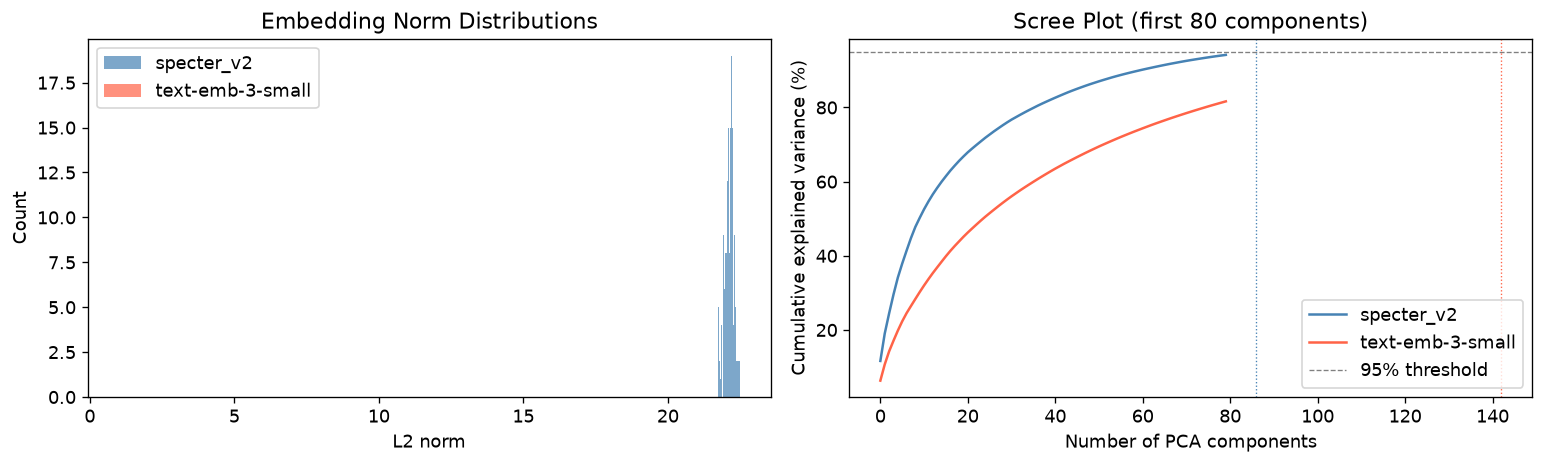

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# L2 norm distributions
axes[0].hist(norms_sp, bins=30, alpha=0.7, label='specter_v2', color='steelblue')
axes[0].hist(norms_oa, bins=30, alpha=0.7, label='text-emb-3-small', color='tomato')
axes[0].set_xlabel('L2 norm')
axes[0].set_ylabel('Count')
axes[0].set_title('Embedding Norm Distributions')
axes[0].legend()

# PCA scree plots
k_show = 80
axes[1].plot(np.cumsum(pca_sp.explained_variance_ratio_[:k_show]) * 100,
             label='specter_v2', color='steelblue')
axes[1].plot(np.cumsum(pca_oa.explained_variance_ratio_[:k_show]) * 100,
             label='text-emb-3-small', color='tomato')
axes[1].axhline(95, color='gray', linestyle='--', linewidth=0.8, label='95% threshold')
axes[1].axvline(eff_dim_sp, color='steelblue', linestyle=':', linewidth=0.8)
axes[1].axvline(eff_dim_oa, color='tomato', linestyle=':', linewidth=0.8)
axes[1].set_xlabel('Number of PCA components')
axes[1].set_ylabel('Cumulative explained variance (%)')
axes[1].set_title('Scree Plot (first 80 components)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Section 2 — Dimensionality Reduction & Visualisation

Each embedding space reduced independently to 2D via PCA and UMAP, coloured by year, citation count, and field of study.

In [6]:
import umap

# PCA to 2D
pca2_sp = PCA(n_components=2, random_state=42).fit_transform(X_sp)
pca2_oa = PCA(n_components=2, random_state=42).fit_transform(X_oa)

# UMAP to 2D (fit on full embeddings)
reducer_sp = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
reducer_oa = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
umap2_sp = reducer_sp.fit_transform(X_sp)
umap2_oa = reducer_oa.fit_transform(X_oa)

print("Reductions complete.")

Reductions complete.


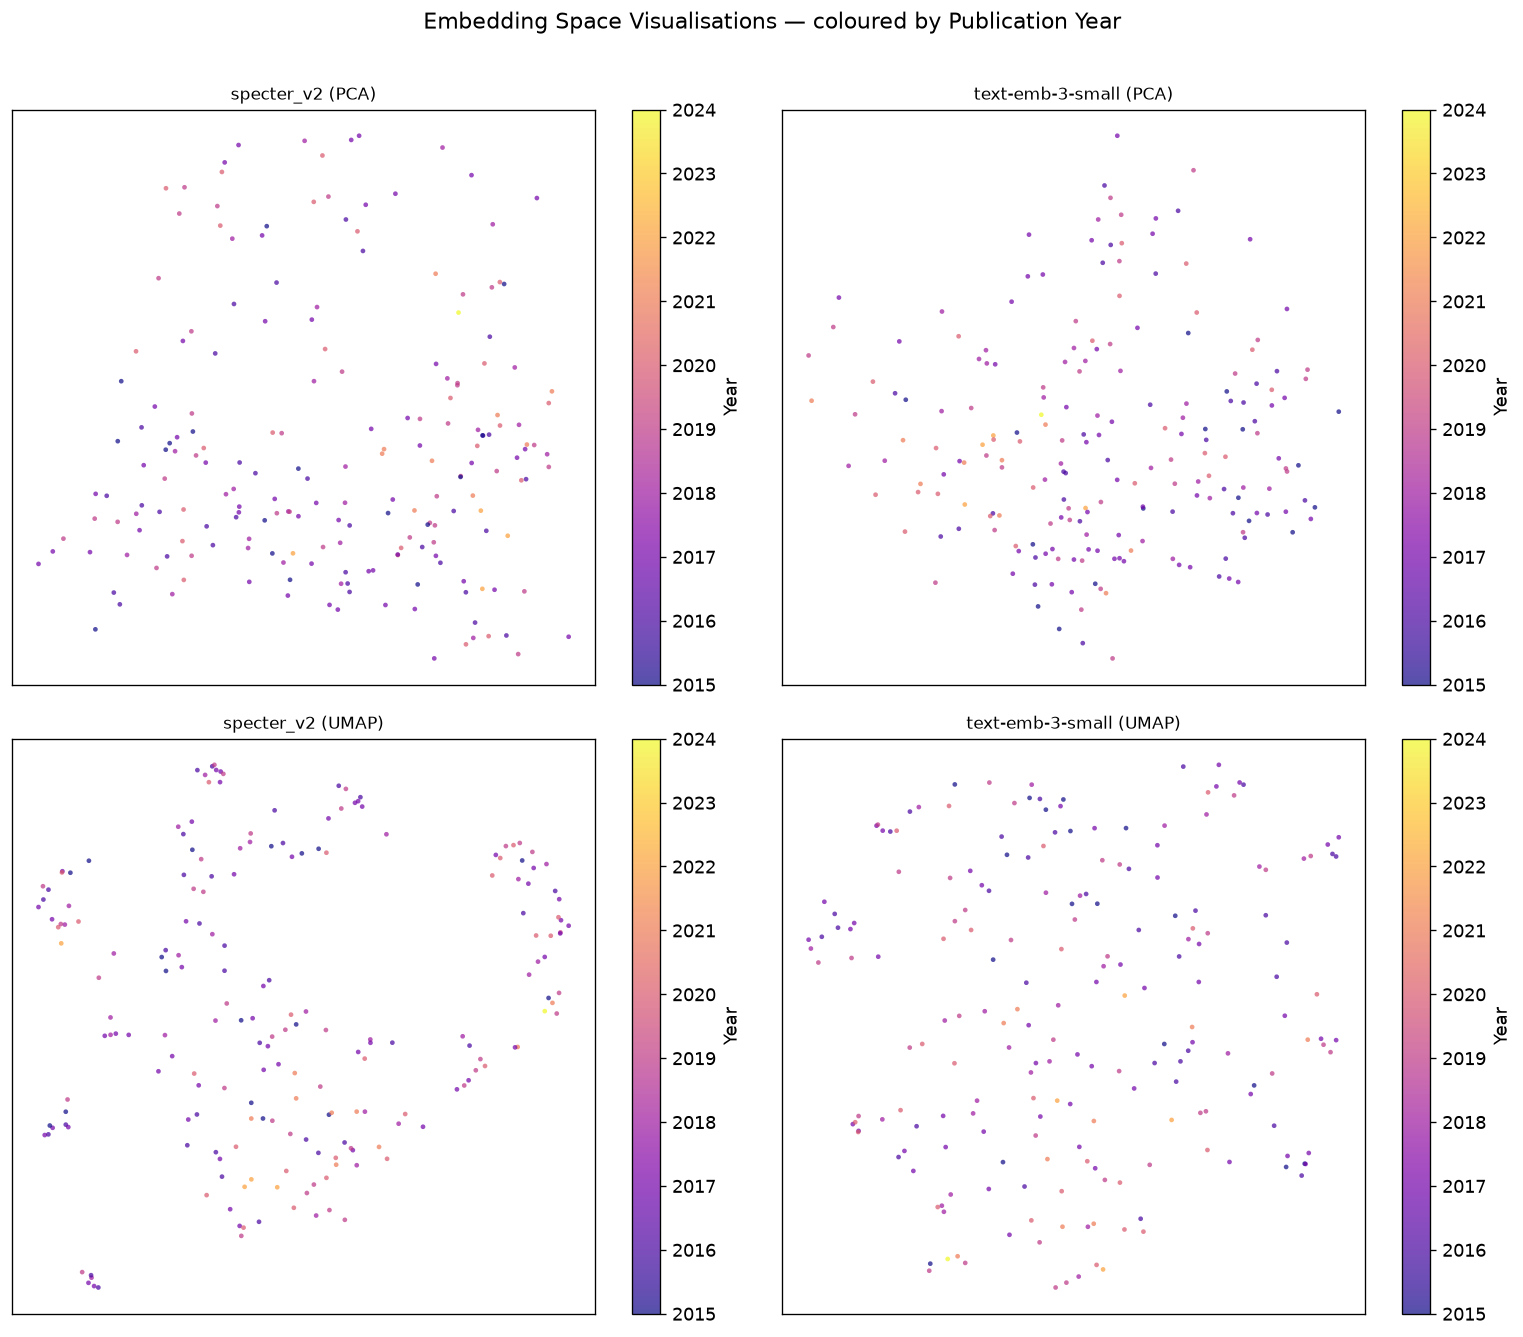

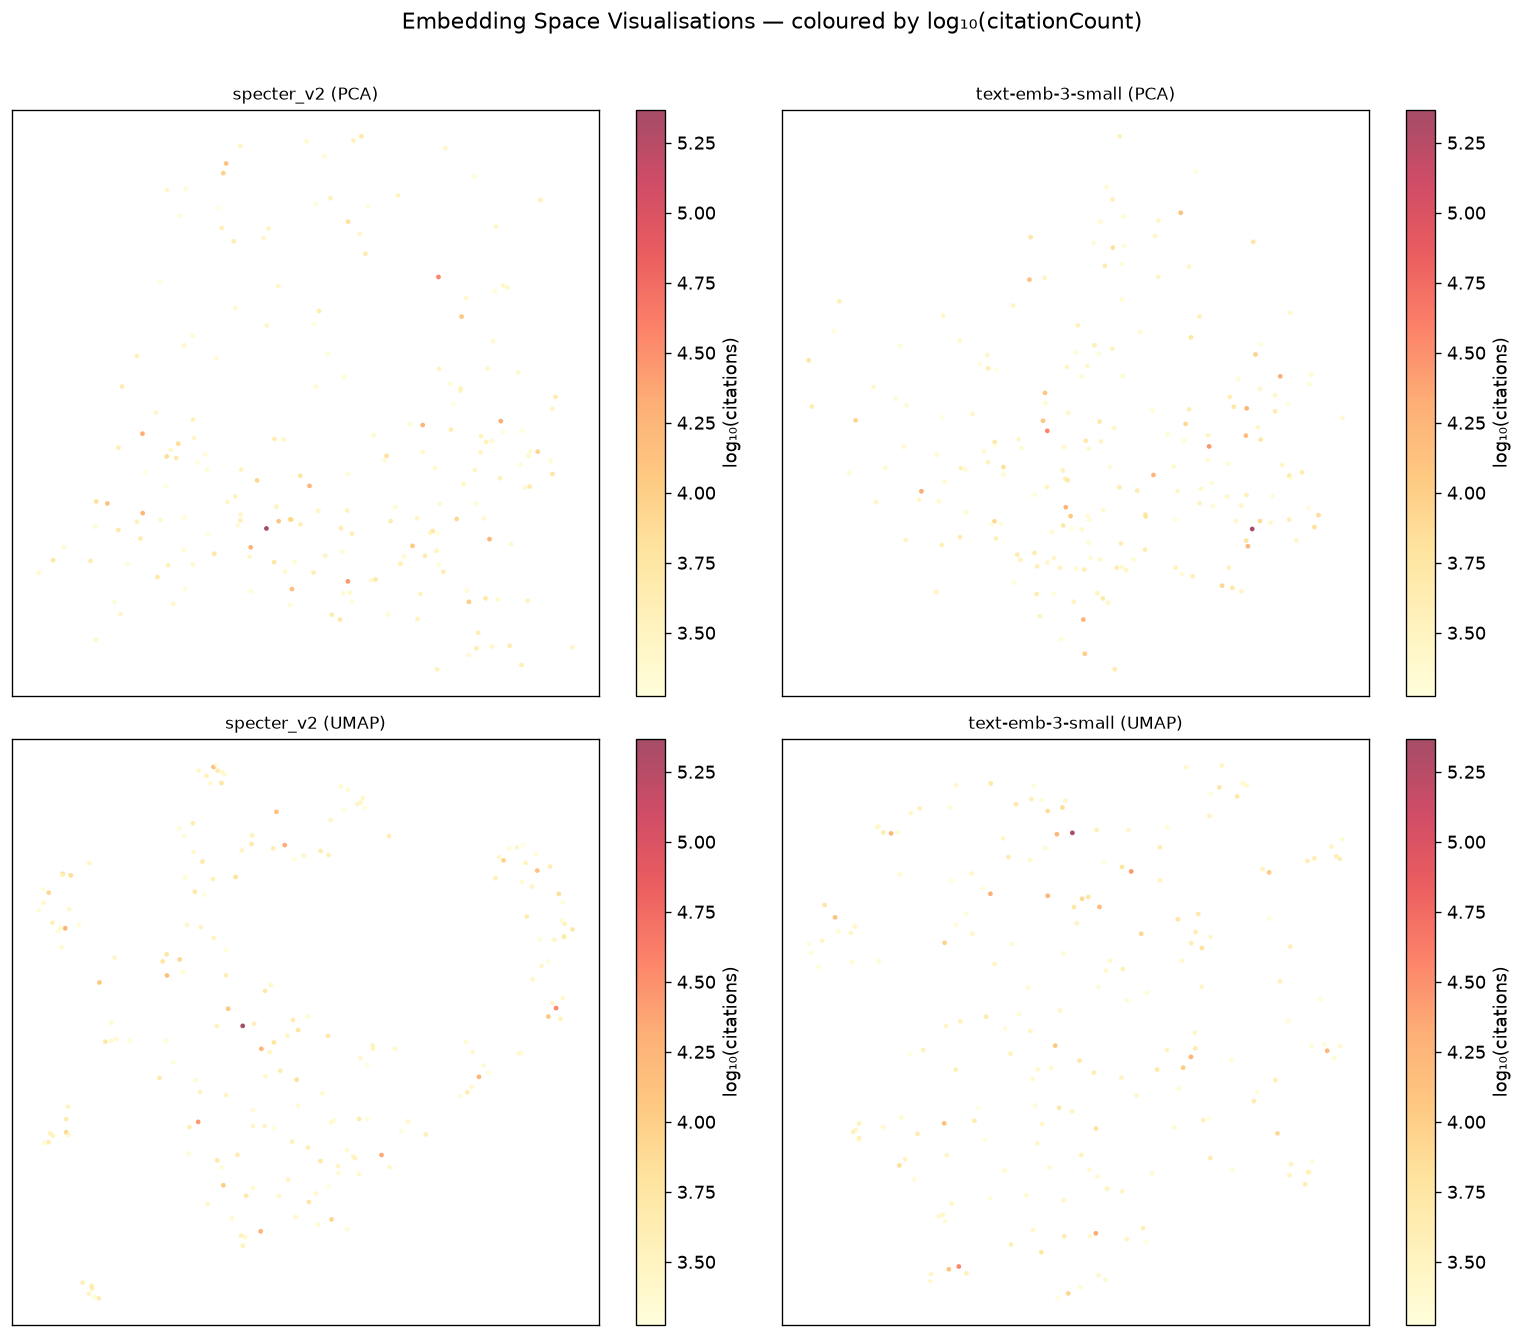

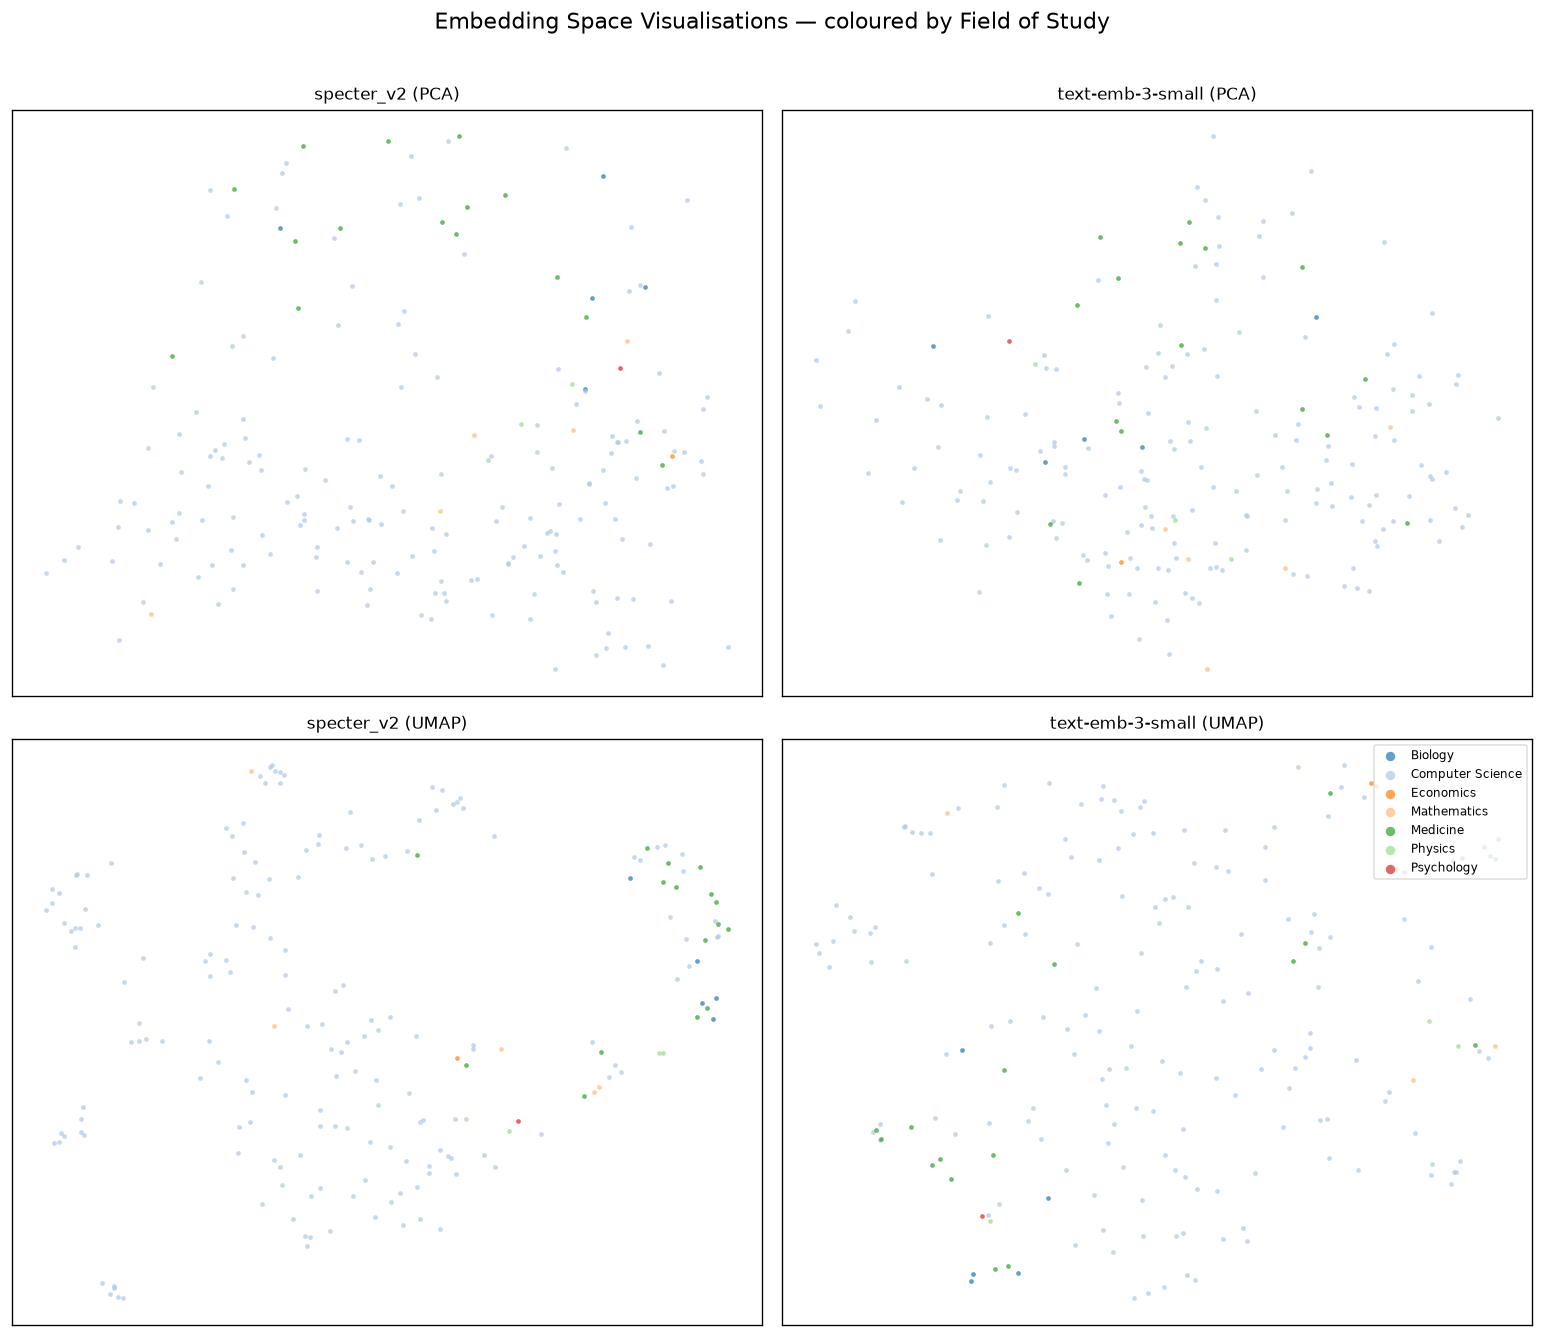

In [7]:
def scatter_panel(ax, coords, color_vals, title, cmap='viridis', label=None):
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=color_vals, cmap=cmap,
                    s=8, alpha=0.7, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    return sc

def categorical_scatter(ax, coords, labels, title):
    unique = sorted(set(labels))
    palette = cm.tab20.colors
    for i, lab in enumerate(unique):
        mask = np.array(labels) == lab
        ax.scatter(coords[mask, 0], coords[mask, 1], s=8, alpha=0.7,
                   label=lab, color=palette[i % len(palette)], linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

year_vals = df['year'].fillna(df['year'].median()).values
cite_vals = df['log_citations'].values
field_vals = df['field'].values

# --- Plot 1: coloured by year ---
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle('Embedding Space Visualisations — coloured by Publication Year', fontsize=13, y=1.01)
for ax, coords, name in [
    (axes[0, 0], pca2_sp,  'specter_v2 (PCA)'),
    (axes[0, 1], pca2_oa,  'text-emb-3-small (PCA)'),
    (axes[1, 0], umap2_sp, 'specter_v2 (UMAP)'),
    (axes[1, 1], umap2_oa, 'text-emb-3-small (UMAP)'),
]:
    sc = scatter_panel(ax, coords, year_vals, name, cmap='plasma')
    plt.colorbar(sc, ax=ax, label='Year')
plt.tight_layout()
plt.show()

# --- Plot 2: coloured by log citation count ---
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle('Embedding Space Visualisations — coloured by log₁₀(citationCount)', fontsize=13, y=1.01)
for ax, coords, name in [
    (axes[0, 0], pca2_sp,  'specter_v2 (PCA)'),
    (axes[0, 1], pca2_oa,  'text-emb-3-small (PCA)'),
    (axes[1, 0], umap2_sp, 'specter_v2 (UMAP)'),
    (axes[1, 1], umap2_oa, 'text-emb-3-small (UMAP)'),
]:
    sc = scatter_panel(ax, coords, cite_vals, name, cmap='YlOrRd')
    plt.colorbar(sc, ax=ax, label='log₁₀(citations)')
plt.tight_layout()
plt.show()

# --- Plot 3: coloured by field of study ---
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle('Embedding Space Visualisations — coloured by Field of Study', fontsize=13, y=1.01)
for ax, coords, name in [
    (axes[0, 0], pca2_sp,  'specter_v2 (PCA)'),
    (axes[0, 1], pca2_oa,  'text-emb-3-small (PCA)'),
    (axes[1, 0], umap2_sp, 'specter_v2 (UMAP)'),
    (axes[1, 1], umap2_oa, 'text-emb-3-small (UMAP)'),
]:
    categorical_scatter(ax, coords, field_vals, name)
axes[1, 1].legend(loc='upper right', fontsize=7, markerscale=2, framealpha=0.6)
plt.tight_layout()
plt.show()

## Section 3 — Semantic Clustering Quality

**Silhouette score** measures how tight clusters are relative to their neighbours. Ranges from -1 (wrong cluster) to +1 (well-separated). Higher is better. Computed without any ground-truth labels.

**Adjusted Rand Index (ARI)** compares cluster assignments against field-of-study labels. 0 = random agreement, 1 = perfect match.

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
field_encoded = le.fit_transform(field_vals)

results_clustering = []
for k in [10, 15, 20, 25]:
    for name, X, umap2 in [('specter_v2', X_sp, umap2_sp), ('text-emb-3-small', X_oa, umap2_oa)]:
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
        labels = km.labels_
        sil = silhouette_score(X, labels, sample_size=min(len(X), 500), random_state=42)
        ari = adjusted_rand_score(field_encoded, labels)
        results_clustering.append({'model': name, 'k': k, 'silhouette': sil, 'ARI_vs_field': ari})

clust_df = pd.DataFrame(results_clustering)
display(clust_df.pivot_table(index='k', columns='model', values=['silhouette', 'ARI_vs_field']).round(4))

ARI_vs_field                  silhouette                 
model   specter_v2 text-emb-3-small specter_v2 text-emb-3-small
k                                                              
10          0.0279           0.0328     0.0734           0.0258
15          0.0113           0.0152     0.1026           0.0338
20          0.0060           0.0064     0.0976           0.0404
25          0.0126           0.0097     0.1120           0.0476

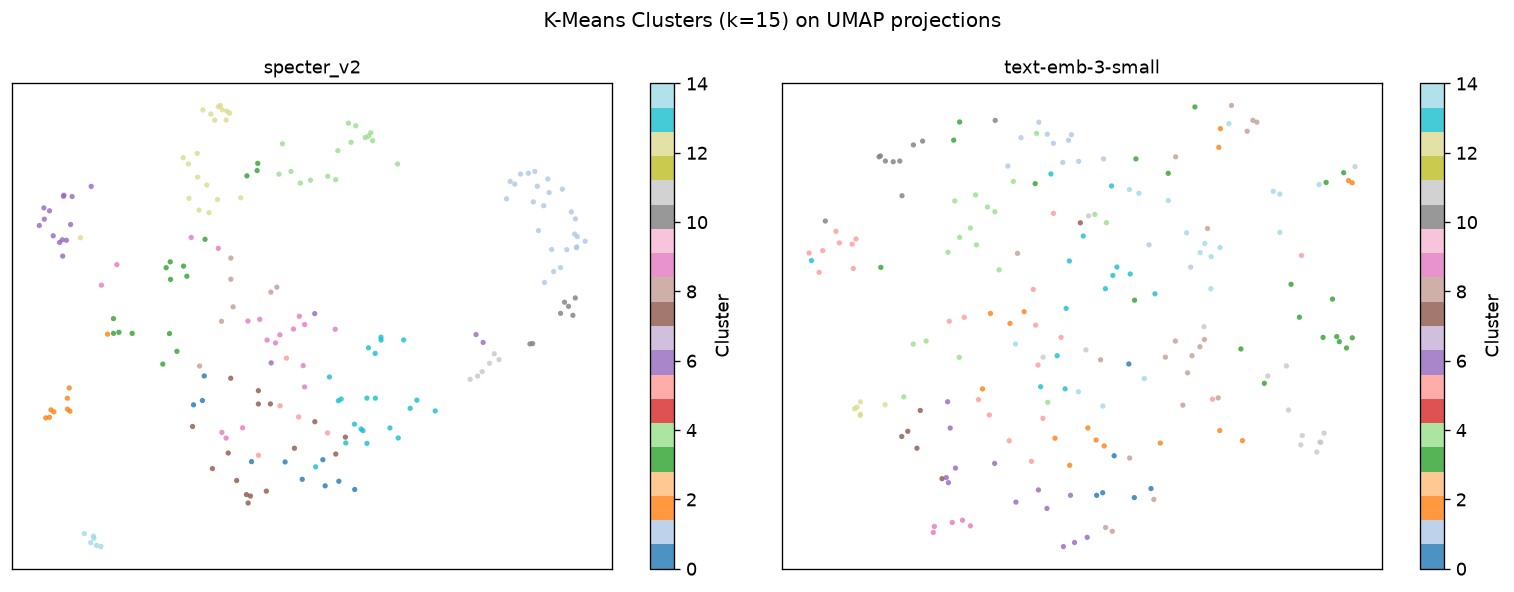

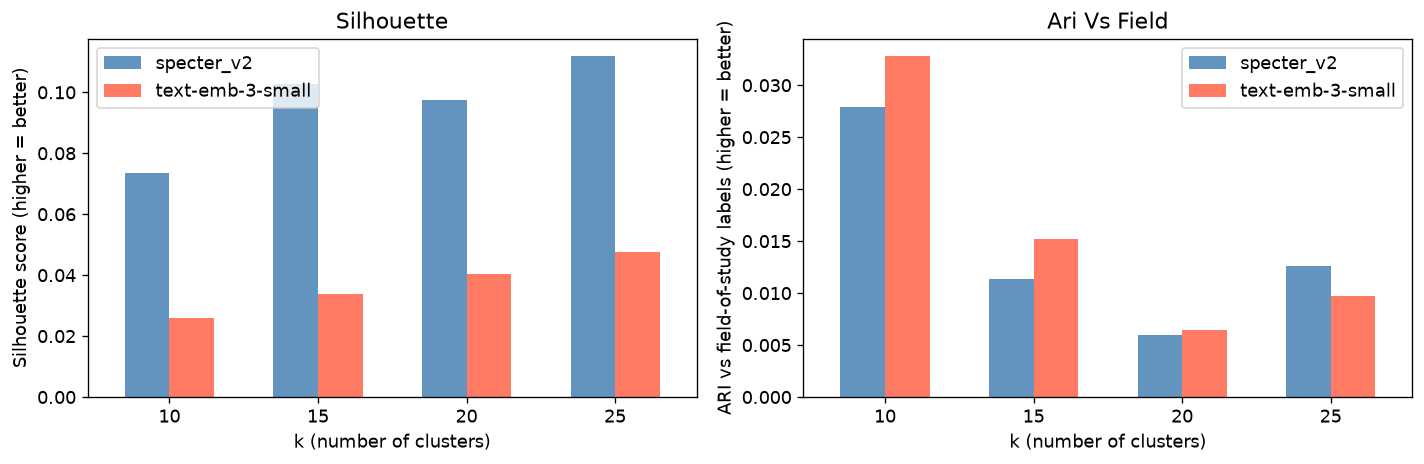

In [9]:
# Visualise k=15 cluster assignments on UMAP
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('K-Means Clusters (k=15) on UMAP projections', fontsize=12)

for ax, X, umap2, name in [
    (axes[0], X_sp, umap2_sp, 'specter_v2'),
    (axes[1], X_oa, umap2_oa, 'text-emb-3-small'),
]:
    km = KMeans(n_clusters=15, random_state=42, n_init=10).fit(X)
    sc = ax.scatter(umap2[:, 0], umap2[:, 1], c=km.labels_, cmap='tab20',
                    s=10, alpha=0.8, linewidths=0)
    ax.set_title(f'{name}', fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(sc, ax=ax, label='Cluster')

plt.tight_layout()
plt.show()

# Silhouette score comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, ylabel in [
    (axes[0], 'silhouette', 'Silhouette score (higher = better)'),
    (axes[1], 'ARI_vs_field', 'ARI vs field-of-study labels (higher = better)'),
]:
    pivot = clust_df.pivot(index='k', columns='model', values=metric)
    pivot.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], alpha=0.85, width=0.6)
    ax.set_xlabel('k (number of clusters)')
    ax.set_ylabel(ylabel)
    ax.set_title(metric.replace('_', ' ').title())
    ax.legend(title='')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Section 4 — Search Quality via Vector Search API

20 benchmark queries across complexity levels. For each query both models are called with `n_results=20` via the `vector_search()` function.

**Metrics:**
- **avg_distance@k** — mean cosine distance of top-k results; lower & tighter = more confident retrieval
- **distance_gap** — gap between rank-k and rank-(k+1) distance; larger gap = cleaner relevance boundary
- **agreement@k** — Jaccard similarity of top-k result sets between models; 1 = identical, 0 = no overlap
- **rank_correlation** — Spearman ρ between model rankings over the union result pool

In [10]:
from scipy.stats import spearmanr
from literature_ai.core.search.vector_search import vector_search_async

QUERIES = [
    # Core DL
    "attention mechanisms in transformer architectures",
    "ResNet residual connections image recognition",
    "recurrent neural networks sequence modelling",
    # Specific methods
    "graph neural networks molecular property prediction",
    "contrastive self-supervised learning representations",
    "variational autoencoder latent space generation",
    "diffusion models image synthesis",
    # Applied / cross-domain
    "machine learning drug discovery protein structure",
    "NLP scientific literature review automation",
    "reinforcement learning robotics control",
    "computer vision medical imaging segmentation",
    # General / broad
    "deep learning survey overview",
    "transfer learning fine-tuning pretrained models",
    "neural architecture search AutoML",
    "federated learning privacy distributed training",
    # Ambiguous / tricky
    "efficient training large models",
    "data augmentation robustness generalisation",
    "knowledge distillation model compression",
    "explainability interpretability neural networks",
    "multi-modal learning vision language",
]

def jaccard(set_a, set_b):
    a, b = set(set_a), set(set_b)
    return len(a & b) / len(a | b) if a | b else 0.0

N_RESULTS = 20
search_records = []

for q in QUERIES:
    sp_results = await vector_search_async(q, run_id=SPECTER_RUN_ID, n_results=N_RESULTS)
    oa_results = await vector_search_async(q, run_id=OPENAI_RUN_ID, n_results=N_RESULTS)

    sp_ids = [r['paperId'] for r in sp_results]
    oa_ids = [r['paperId'] for r in oa_results]
    sp_dists = [r['distance'] for r in sp_results]
    oa_dists = [r['distance'] for r in oa_results]

    # Rank correlation over union pool
    union_ids = list(dict.fromkeys(sp_ids + oa_ids))  # preserve order, deduplicate
    sp_rank = {pid: i for i, pid in enumerate(sp_ids)}
    oa_rank = {pid: i for i, pid in enumerate(oa_ids)}
    # Assign rank N_RESULTS+1 to papers not retrieved by a model
    sp_ranks_union = [sp_rank.get(pid, N_RESULTS) for pid in union_ids]
    oa_ranks_union = [oa_rank.get(pid, N_RESULTS) for pid in union_ids]
    rho, _ = spearmanr(sp_ranks_union, oa_ranks_union)

    for k in [5, 10, 20]:
        sp_k = sp_dists[:k]
        oa_k = oa_dists[:k]
        gap_sp = (sp_dists[k] - sp_dists[k - 1]) if k < len(sp_dists) else float('nan')
        gap_oa = (oa_dists[k] - oa_dists[k - 1]) if k < len(oa_dists) else float('nan')
        search_records.append({
            'query': q,
            'k': k,
            'avg_dist_sp': np.mean(sp_k),
            'avg_dist_oa': np.mean(oa_k),
            'distance_gap_sp': gap_sp,
            'distance_gap_oa': gap_oa,
            'agreement': jaccard(sp_ids[:k], oa_ids[:k]),
            'rank_corr': rho,
        })

search_df = pd.DataFrame(search_records)
print("Search metrics computed for all queries.")

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 63550.06it/s]
There are adapters available but none are activated for the forward pass.


Search metrics computed for all queries.


In [11]:
# Aggregate summary table
agg = search_df.groupby('k').agg(
    avg_dist_sp=('avg_dist_sp', 'mean'),
    avg_dist_oa=('avg_dist_oa', 'mean'),
    distance_gap_sp=('distance_gap_sp', 'mean'),
    distance_gap_oa=('distance_gap_oa', 'mean'),
    agreement=('agreement', 'mean'),
    rank_corr=('rank_corr', 'mean'),
).round(4)
display(agg)

,avg_dist_sp,avg_dist_oa,distance_gap_sp,distance_gap_oa,agreement,rank_corr
k,,,,,,
5,13.9487,1.0072,0.0924,0.0091,0.3262,-0.0219
10,14.3237,1.0423,0.0404,0.0028,0.3153,-0.0219
20,14.7096,1.0736,NaN,NaN,0.3124,-0.0219


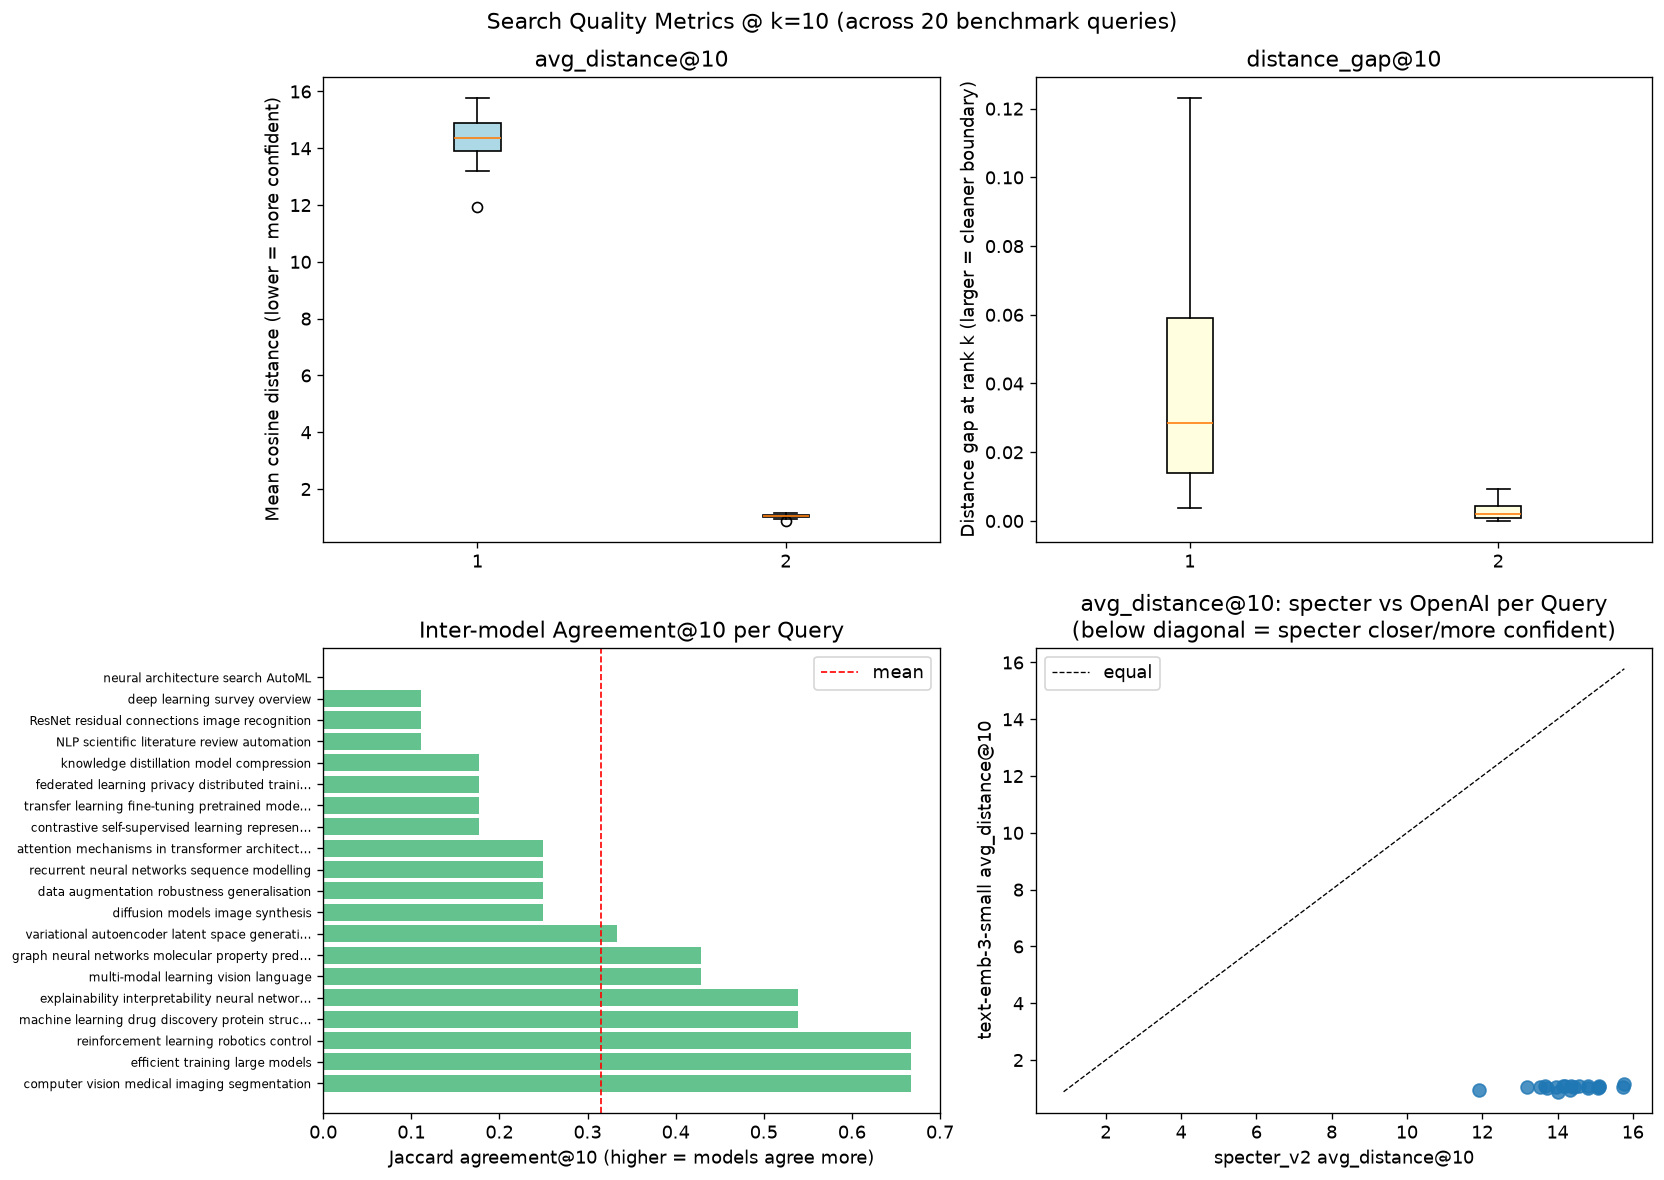

In [14]:
k10 = search_df[search_df['k'] == 10].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Search Quality Metrics @ k=10 (across 20 benchmark queries)', fontsize=13)

# 1. avg_distance@10 box plots
axes[0, 0].boxplot(
    [k10['avg_dist_sp'], k10['avg_dist_oa']],
    label=['specter_v2', 'text-emb-3-small'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
)
axes[0, 0].set_ylabel('Mean cosine distance (lower = more confident)')
axes[0, 0].set_title('avg_distance@10')

# 2. distance_gap@10 box plots
axes[0, 1].boxplot(
    [k10['distance_gap_sp'].dropna(), k10['distance_gap_oa'].dropna()],
    label=['specter_v2', 'text-emb-3-small'],
    patch_artist=True,
    boxprops=dict(facecolor='lightyellow'),
)
axes[0, 1].set_ylabel('Distance gap at rank k (larger = cleaner boundary)')
axes[0, 1].set_title('distance_gap@10')

# 3. agreement@10 bar chart per query
k10_sorted = k10.sort_values('agreement', ascending=False)
axes[1, 0].barh(range(len(k10_sorted)), k10_sorted['agreement'], color='mediumseagreen', alpha=0.8)
axes[1, 0].set_yticks(range(len(k10_sorted)))
axes[1, 0].set_yticklabels([q[:45] + '…' if len(q) > 45 else q
                             for q in k10_sorted['query']], fontsize=7)
axes[1, 0].set_xlabel('Jaccard agreement@10 (higher = models agree more)')
axes[1, 0].set_title('Inter-model Agreement@10 per Query')
axes[1, 0].axvline(k10['agreement'].mean(), color='red', linestyle='--', linewidth=1, label='mean')
axes[1, 0].legend()

# 4. avg_distance scatter (specter vs openai)
axes[1, 1].scatter(k10['avg_dist_sp'], k10['avg_dist_oa'], alpha=0.8, s=60)
lim = [min(k10[['avg_dist_sp', 'avg_dist_oa']].min()), max(k10[['avg_dist_sp', 'avg_dist_oa']].max())]
axes[1, 1].plot(lim, lim, 'k--', linewidth=0.8, label='equal')
axes[1, 1].set_xlabel('specter_v2 avg_distance@10')
axes[1, 1].set_ylabel('text-emb-3-small avg_distance@10')
axes[1, 1].set_title('avg_distance@10: specter vs OpenAI per Query\n(below diagonal = specter closer/more confident)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Rank correlation heatmap per query
rank_by_query = k10[['query', 'rank_corr']].drop_duplicates().sort_values('rank_corr')
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if v < 0 else 'steelblue' for v in rank_by_query['rank_corr']]
ax.barh(range(len(rank_by_query)), rank_by_query['rank_corr'], color=colors, alpha=0.8)
ax.set_yticks(range(len(rank_by_query)))
ax.set_yticklabels([q[:50] + '…' if len(q) > 50 else q for q in rank_by_query['query']], fontsize=8)
ax.set_xlabel('Spearman rank correlation (1 = identical ordering)')
ax.set_title('Rank Correlation Between Models per Query')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(rank_by_query['rank_corr'].mean(), color='red', linestyle='--', linewidth=1, label='mean')
ax.legend()
plt.tight_layout()
plt.show()

## Section 5 — Nearest-Neighbour Agreement

For each paper, we find its top-10 nearest neighbours in each embedding space and compute the **Jaccard similarity** of those neighbour sets. A score of 1.0 means both models agree completely on which papers are similar; 0.0 means total disagreement.

**Hubness score**: skewness of the distribution of how often each paper appears as a nearest neighbour of others. High skew (>1) means a few "hub" papers are retrieved constantly, which dilutes retrieval diversity — a known failure mode of high-dimensional spaces.

In [ ]:
from sklearn.neighbors import NearestNeighbors
from scipy.stats import skew

K_NN = 10
N = len(X_sp)

nn_sp = NearestNeighbors(n_neighbors=K_NN + 1, metric='cosine', algorithm='brute').fit(X_sp)
nn_oa = NearestNeighbors(n_neighbors=K_NN + 1, metric='cosine', algorithm='brute').fit(X_oa)

_, indices_sp = nn_sp.kneighbors(X_sp)  # (N, K_NN+1) — first col is self
_, indices_oa = nn_oa.kneighbors(X_oa)

# Exclude self (index 0) and take top-K
nbrs_sp = indices_sp[:, 1:K_NN + 1]
nbrs_oa = indices_oa[:, 1:K_NN + 1]

# Per-paper Jaccard agreement
agreements = np.array([jaccard(nbrs_sp[i], nbrs_oa[i]) for i in range(N)])

# Hubness: how often is each paper retrieved as a neighbour?
hub_sp = np.bincount(nbrs_sp.flatten(), minlength=N)
hub_oa = np.bincount(nbrs_oa.flatten(), minlength=N)

print(f"NN agreement@{K_NN}:  mean={agreements.mean():.3f}  std={agreements.std():.3f}  median={np.median(agreements):.3f}")
print(f"Hubness (skewness): specter_v2={skew(hub_sp):.3f}  text-emb-3-small={skew(hub_oa):.3f}")
print("  (>1 = moderate hubness, >2 = severe hubness)")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Agreement histogram
axes[0].hist(agreements, bins=20, color='mediumseagreen', alpha=0.85, edgecolor='white')
axes[0].axvline(agreements.mean(), color='red', linestyle='--', linewidth=1.2, label=f'mean={agreements.mean():.3f}')
axes[0].set_xlabel(f'Jaccard agreement@{K_NN} (per paper)')
axes[0].set_ylabel('Number of papers')
axes[0].set_title('NN Agreement Distribution')
axes[0].legend()

# Hubness comparison
axes[1].bar(['specter_v2', 'text-emb-3-small'], [skew(hub_sp), skew(hub_oa)],
            color=['steelblue', 'tomato'], alpha=0.85)
axes[1].axhline(1, color='orange', linestyle='--', linewidth=1, label='moderate hubness threshold')
axes[1].set_ylabel('Skewness of NN retrieval count')
axes[1].set_title('Hubness Score (lower = more uniform retrieval)')
axes[1].legend()

# UMAP hubness maps
sc = axes[2].scatter(umap2_sp[:, 0], umap2_sp[:, 1], c=hub_sp, cmap='hot_r',
                     s=10, alpha=0.85, linewidths=0)
plt.colorbar(sc, ax=axes[2], label='Times retrieved as NN')
axes[2].set_title('specter_v2 hubness map (UMAP)')
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.tight_layout()
plt.show()

# OpenAI hubness map
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(umap2_oa[:, 0], umap2_oa[:, 1], c=hub_oa, cmap='hot_r',
                s=10, alpha=0.85, linewidths=0)
plt.colorbar(sc, ax=ax, label='Times retrieved as NN')
ax.set_title('text-emb-3-small hubness map (UMAP)')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

In [ ]:
# Case studies: papers with highest / lowest agreement
top_agree_idx = agreements.argsort()[-5:][::-1]
low_agree_idx = agreements.argsort()[:5]

print("=== Papers with HIGHEST NN agreement (both models agree on neighbours) ===")
for i in top_agree_idx:
    row = df.iloc[i]
    print(f"  [{agreements[i]:.3f}] {row['title'][:90]}")

print("\n=== Papers with LOWEST NN agreement (models disagree most on neighbours) ===")
for i in low_agree_idx:
    row = df.iloc[i]
    print(f"  [{agreements[i]:.3f}] {row['title'][:90]}")

## Section 6 — Cross-Model Geometry

**Linear CKA** answers: do the two models organise the corpus geometrically in the same way? It compares the N×N gram matrices (all-pairs dot products) from each model. Score of 1 = identical structure; 0 = unrelated. Crucially, it works even though the two embedding spaces have different dimensions.

**Spearman ρ of pairwise distances** checks whether the relative distances between paper pairs are correlated across models — a complementary angle-vs-scale measure.

In [ ]:
def linear_cka(X, Y):
    """Linear Centered Kernel Alignment between X (N,d1) and Y (N,d2)."""
    # Centre
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)
    # Gram matrices
    K = X @ X.T
    L = Y @ Y.T
    # HSIC estimates (Frobenius inner product of centred gram matrices)
    hsic_kl = np.linalg.norm(K * L, 'fro')  # element-wise product then Frobenius
    # Correct: HSIC(K,L) = <K_c, L_c>_F
    hsic_kl = np.sum(K * L)
    hsic_kk = np.sum(K * K)
    hsic_ll = np.sum(L * L)
    return float(hsic_kl / np.sqrt(hsic_kk * hsic_ll))

cka_score = linear_cka(X_sp, X_oa)
print(f"Linear CKA (specter_v2 vs text-emb-3-small): {cka_score:.4f}")
print("  (0 = unrelated geometry, 1 = identical geometry)")

In [ ]:
# Spearman ρ of pairwise cosine distances (sampled)
N_PAIRS = min(2000, N * (N - 1) // 2)
idx_a = RNG.integers(0, N, N_PAIRS)
idx_b = RNG.integers(0, N, N_PAIRS)
same = idx_a == idx_b
idx_b[same] = (idx_b[same] + 1) % N

def cosine_dist(X, i, j):
    xi, xj = X[i], X[j]
    norms = np.linalg.norm(xi, axis=1) * np.linalg.norm(xj, axis=1) + 1e-10
    return 1.0 - (xi * xj).sum(axis=1) / norms

dists_sp = cosine_dist(X_sp, idx_a, idx_b)
dists_oa = cosine_dist(X_oa, idx_a, idx_b)

rho_dist, p_dist = spearmanr(dists_sp, dists_oa)
print(f"Spearman ρ of pairwise cosine distances: {rho_dist:.4f}  (p={p_dist:.2e})")
print("  (1 = models agree on relative distances, 0 = no agreement)")

# Scatter plot of pairwise distances
sample_mask = RNG.choice(N_PAIRS, size=min(500, N_PAIRS), replace=False)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(dists_sp[sample_mask], dists_oa[sample_mask], alpha=0.4, s=10)
lim = [0, max(dists_sp.max(), dists_oa.max()) * 1.05]
ax.plot(lim, lim, 'r--', linewidth=0.8, label='equal')
ax.set_xlabel('specter_v2 cosine distance')
ax.set_ylabel('text-emb-3-small cosine distance')
ax.set_title(f'Pairwise Cosine Distance Correlation\n(Spearman ρ = {rho_dist:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

## Section 7 — Summary Dashboard

In [ ]:
k10_agg = search_df[search_df['k'] == 10]

summary = pd.DataFrame([
    # Embedding space properties
    {'Category': 'Space properties', 'Metric': 'L2 norm mean',
     'specter_v2': f"{norms_sp.mean():.3f}", 'text-emb-3-small': f"{norms_oa.mean():.3f}",
     'Note': 'higher norm ≠ better'},
    {'Category': 'Space properties', 'Metric': 'L2 norm std',
     'specter_v2': f"{norms_sp.std():.3f}", 'text-emb-3-small': f"{norms_oa.std():.3f}",
     'Note': 'lower std = more uniform'},
    {'Category': 'Space properties', 'Metric': 'Mean pairwise cosine sim',
     'specter_v2': f"{mpc_sp:.4f}", 'text-emb-3-small': f"{mpc_oa:.4f}",
     'Note': 'lower = better spread (closer to 0)'},
    {'Category': 'Space properties', 'Metric': 'Effective dim (95% PCA var)',
     'specter_v2': str(eff_dim_sp), 'text-emb-3-small': str(eff_dim_oa),
     'Note': 'higher = richer representation'},
    # Clustering
    {'Category': 'Clustering (k=15)', 'Metric': 'Silhouette score',
     'specter_v2': f"{clust_df[(clust_df.k==15)&(clust_df.model=='specter_v2')]['silhouette'].values[0]:.4f}",
     'text-emb-3-small': f"{clust_df[(clust_df.k==15)&(clust_df.model=='text-embedding-3-small')]['silhouette'].values[0]:.4f}",
     'Note': 'higher = tighter, better-separated clusters'},
    {'Category': 'Clustering (k=15)', 'Metric': 'ARI vs field labels',
     'specter_v2': f"{clust_df[(clust_df.k==15)&(clust_df.model=='specter_v2')]['ARI_vs_field'].values[0]:.4f}",
     'text-emb-3-small': f"{clust_df[(clust_df.k==15)&(clust_df.model=='text-embedding-3-small')]['ARI_vs_field'].values[0]:.4f}",
     'Note': 'higher = clusters align better with fields'},
    # Search quality
    {'Category': 'Search quality (k=10)', 'Metric': 'avg_distance@10',
     'specter_v2': f"{k10_agg['avg_dist_sp'].mean():.4f}",
     'text-emb-3-small': f"{k10_agg['avg_dist_oa'].mean():.4f}",
     'Note': 'lower = results closer to query'},
    {'Category': 'Search quality (k=10)', 'Metric': 'distance_gap@10',
     'specter_v2': f"{k10_agg['distance_gap_sp'].mean():.4f}",
     'text-emb-3-small': f"{k10_agg['distance_gap_oa'].mean():.4f}",
     'Note': 'higher = cleaner relevance boundary'},
    {'Category': 'Search quality (k=10)', 'Metric': 'agreement@10 (mean)',
     'specter_v2': '—', 'text-emb-3-small': f"{k10_agg['agreement'].mean():.4f}",
     'Note': 'inter-model Jaccard; 1=identical results'},
    {'Category': 'Search quality (k=10)', 'Metric': 'rank_correlation (mean Spearman ρ)',
     'specter_v2': '—', 'text-emb-3-small': f"{k10_agg['rank_corr'].mean():.4f}",
     'Note': 'inter-model rank agreement'},
    # NN agreement
    {'Category': 'NN agreement', 'Metric': f'mean Jaccard@{K_NN} (paper-level)',
     'specter_v2': '—', 'text-emb-3-small': f"{agreements.mean():.4f}",
     'Note': 'how often models agree on NN'},
    {'Category': 'NN agreement', 'Metric': 'Hubness skewness',
     'specter_v2': f"{skew(hub_sp):.3f}", 'text-emb-3-small': f"{skew(hub_oa):.3f}",
     'Note': 'lower = less hubness; >2 = severe'},
    # Cross-model
    {'Category': 'Cross-model geometry', 'Metric': 'Linear CKA',
     'specter_v2': '—', 'text-emb-3-small': f"{cka_score:.4f}",
     'Note': '0=unrelated structure, 1=identical structure'},
    {'Category': 'Cross-model geometry', 'Metric': 'Pairwise distance Spearman ρ',
     'specter_v2': '—', 'text-emb-3-small': f"{rho_dist:.4f}",
     'Note': 'agreement on relative inter-paper distances'},
])

display(summary.set_index(['Category', 'Metric']))

In [ ]:
print("""
=== RECOMMENDATION ===

Inspect the table above. Key questions to answer:

1. SPACE QUALITY
   - Which model has lower mean pairwise cosine similarity? (better spread)
   - Which has higher effective dimensionality? (richer representation)

2. SEMANTIC STRUCTURE
   - Which clusters better align with fields of study? (ARI)
   - Which has higher silhouette score? (internal cluster quality)

3. RETRIEVAL CONFIDENCE
   - Which has lower avg_distance@10? (results closer to query)
   - Which has a larger distance_gap? (cleaner relevant/irrelevant boundary)

4. HUBNESS
   - Which has lower hubness skewness? (diverse retrieval, no dominant hubs)

5. MODEL AGREEMENT
   - CKA and rank correlation reveal how similar their "world models" are.
   - Low agreement means the models complement each other; high means either
     would suffice and the cheaper one is preferable.

NOTE: With only ~200 papers, all metrics have high variance. Re-run this
notebook after expanding the corpus for production-grade conclusions.
""")